# Analysis: Stuttgart vs. Mainz Beer Consumption Survey Data

This notebook analyzes the differences between the original Stuttgart survey data and the LLM-adapted Mainz data based on market research and regional preferences.

In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [18]:
# Load the data files
base_path = Path('/Users/f/Repositories/Bierprojekt')

# Load statistical summaries
stuttgart_data = pd.read_csv(base_path / 'src/llm/stat_summary_NoNaNs_100.csv')
mainz_data = pd.read_csv(base_path / 'data/synthetic_mainz_stat_summary.csv')

# Load questionnaire for context
questionnaire = pd.read_csv(base_path / 'data/fragebogen.csv')

# Load short question descriptions
fragen_short = pd.read_csv(base_path / 'data/fragen_short.csv')

print("Data loaded successfully!")
print(f"Stuttgart data shape: {stuttgart_data.shape}")
print(f"Mainz data shape: {mainz_data.shape}")
print(f"Questionnaire shape: {questionnaire.shape}")
print(f"Short questions shape: {fragen_short.shape}")

Data loaded successfully!
Stuttgart data shape: (83, 7)
Mainz data shape: (83, 7)
Questionnaire shape: (85, 3)
Short questions shape: (85, 2)


In [19]:
# Display first few rows to understand structure
print("Stuttgart Data Sample:")
print(stuttgart_data.head())
print("\nMainz Data Sample:")
print(mainz_data.head())

Stuttgart Data Sample:
  Column  Mean       Std  Min  Max  Mode  Frequency
0     Q1  3.13  1.137146  1.0  5.0   3.0         38
1    Q2A  2.39  0.563826  1.0  3.0   2.0         53
2    Q2B  2.58  0.550999  1.0  3.0   3.0         61
3    Q2C  1.42  0.550999  1.0  3.0   1.0         61
4    Q2D  1.40  0.565685  1.0  3.0   1.0         64

Mainz Data Sample:
  Column  Mean       Std  Min  Max  Mode  Frequency
0     Q1  3.50  1.200000  1.0  5.0   4.0         40
1    Q2A  2.39  0.563826  1.0  3.0   2.0         53
2    Q2B  2.58  0.550999  1.0  3.0   3.0         61
3    Q2C  1.20  0.550999  1.0  3.0   1.0         70
4    Q2D  1.20  0.565685  1.0  3.0   1.0         72


## Data Preparation and Merging

In [20]:
# Merge the datasets for comparison
comparison_df = stuttgart_data.merge(mainz_data, on='Column', suffixes=('_Stuttgart', '_Mainz'))

# Add questionnaire information
comparison_df = comparison_df.merge(questionnaire, left_on='Column', right_on='variable', how='left')

# Add short question descriptions
comparison_df = comparison_df.merge(fragen_short, left_on='Column', right_on='variable', how='left')

# Calculate differences
comparison_df['Mean_Diff'] = comparison_df['Mean_Mainz'] - comparison_df['Mean_Stuttgart']
comparison_df['Std_Diff'] = comparison_df['Std_Mainz'] - comparison_df['Std_Stuttgart']
comparison_df['Mode_Diff'] = comparison_df['Mode_Mainz'] - comparison_df['Mode_Stuttgart']

print(f"Combined dataset shape: {comparison_df.shape}")
print("\nColumns:", comparison_df.columns.tolist())

Combined dataset shape: (83, 21)

Columns: ['Column', 'Mean_Stuttgart', 'Std_Stuttgart', 'Min_Stuttgart', 'Max_Stuttgart', 'Mode_Stuttgart', 'Frequency_Stuttgart', 'Mean_Mainz', 'Std_Mainz', 'Min_Mainz', 'Max_Mainz', 'Mode_Mainz', 'Frequency_Mainz', 'variable_x', 'question', 'options', 'variable_y', 'summary', 'Mean_Diff', 'Std_Diff', 'Mode_Diff']


## Overall Distribution Changes

In [21]:
# Summary statistics of changes
print("=== SUMMARY OF CHANGES ===")
print(f"Questions analyzed: {len(comparison_df)}")
print(f"Mean changes - Average: {comparison_df['Mean_Diff'].mean():.3f}, Std: {comparison_df['Mean_Diff'].std():.3f}")
print(f"Std changes - Average: {comparison_df['Std_Diff'].mean():.3f}, Std: {comparison_df['Std_Diff'].std():.3f}")
print(f"Mode changes - Non-zero changes: {(comparison_df['Mode_Diff'] != 0).sum()}")

# Show questions with largest changes
print("\n=== TOP 10 LARGEST MEAN INCREASES ===")
top_increases = comparison_df.nlargest(10, 'Mean_Diff')[['Column', 'question', 'Mean_Stuttgart', 'Mean_Mainz', 'Mean_Diff']]
for _, row in top_increases.iterrows():
    print(f"{row['Column']}: {row['Mean_Diff']:+.2f} ({row['Mean_Stuttgart']:.2f} → {row['Mean_Mainz']:.2f})")
    print(f"  {row['question'][:80]}...")
    print()

print("\n=== TOP 10 LARGEST MEAN DECREASES ===")
top_decreases = comparison_df.nsmallest(10, 'Mean_Diff')[['Column', 'question', 'Mean_Stuttgart', 'Mean_Mainz', 'Mean_Diff']]
for _, row in top_decreases.iterrows():
    print(f"{row['Column']}: {row['Mean_Diff']:+.2f} ({row['Mean_Stuttgart']:.2f} → {row['Mean_Mainz']:.2f})")
    print(f"  {row['question'][:80]}...")
    print()

=== SUMMARY OF CHANGES ===
Questions analyzed: 83
Mean changes - Average: 0.211, Std: 1.054
Std changes - Average: -0.031, Std: 0.287
Mode changes - Non-zero changes: 4

=== TOP 10 LARGEST MEAN INCREASES ===
Q15: +9.35 (1.65 → 11.00)
  In welchem Bundesland wohnen Sie derzeit?...

Q9I: +1.52 (2.67 → 4.19)
  Pils/Pilsner...

Q8E: +1.23 (2.27 → 3.50)
  Nachhaltige Produktion des Getränks...

Q8F: +1.11 (2.89 → 4.00)
  Herkunftsregion der Marke...

Q7B: +0.71 (2.79 → 3.50)
  Mir ist es sehr wichtig, dass Getränke umweltfreundlich hergestellt und vertrieb...

Q7E: +0.47 (2.53 → 3.00)
  Mir ist es sehr wichtig, dass bei der Herstellung von Getränken keine Inhaltssto...

Q8K: +0.47 (3.33 → 3.80)
  Empfehlung von Dritten...

Q12B: +0.46 (2.34 → 2.80)
  Werbung auf den Social-Media-Kanälen von Herstellern oder Händlern...

Q1: +0.37 (3.13 → 3.50)
  Wie häufig trinken Sie grundsätzlich alkoholfreies oder alkoholhaltiges Bier bzw...

Q4H: +0.37 (1.13 → 1.50)
  Lieferservice/Online-Lebensmittelha

## Visualization of Changes

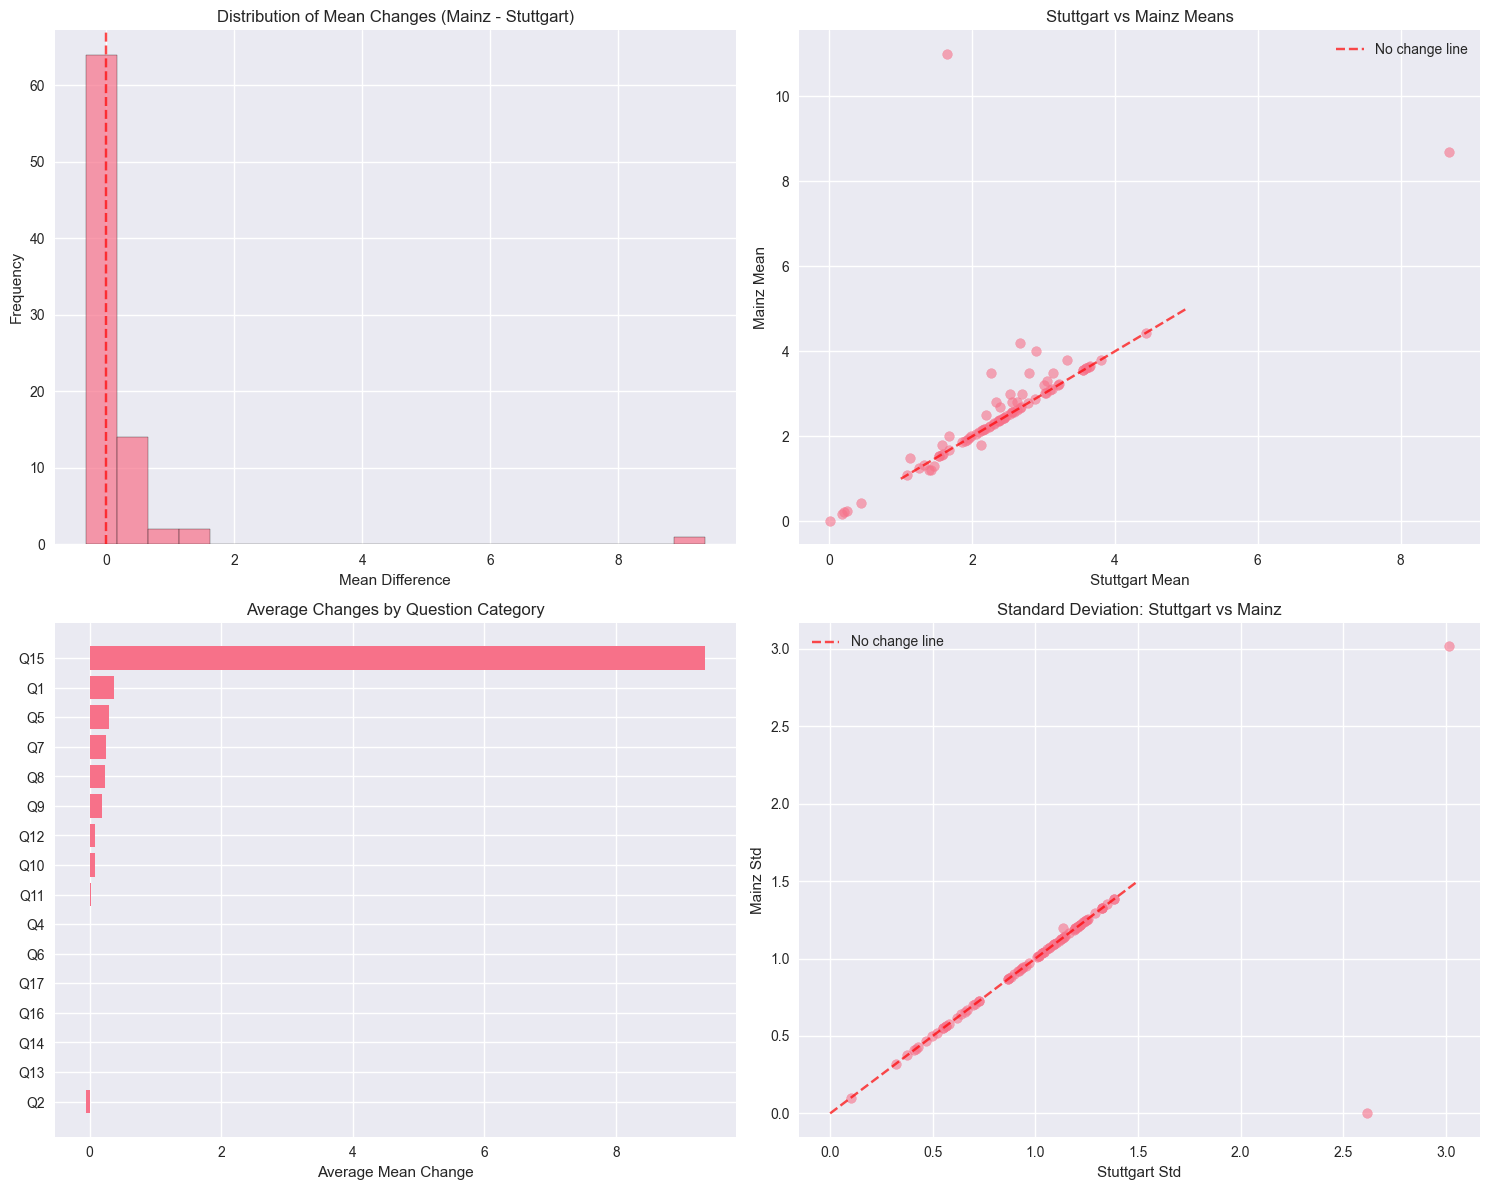

In [22]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of mean changes
axes[0,0].hist(comparison_df['Mean_Diff'], bins=20, alpha=0.7, edgecolor='black')
axes[0,0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0,0].set_title('Distribution of Mean Changes (Mainz - Stuttgart)')
axes[0,0].set_xlabel('Mean Difference')
axes[0,0].set_ylabel('Frequency')

# 2. Scatter plot: Stuttgart vs Mainz means
axes[0,1].scatter(comparison_df['Mean_Stuttgart'], comparison_df['Mean_Mainz'], alpha=0.6)
axes[0,1].plot([1, 5], [1, 5], 'r--', alpha=0.7, label='No change line')
axes[0,1].set_xlabel('Stuttgart Mean')
axes[0,1].set_ylabel('Mainz Mean')
axes[0,1].set_title('Stuttgart vs Mainz Means')
axes[0,1].legend()

# 3. Changes by question category
q_categories = comparison_df['Column'].str.extract(r'(Q\d+)')[0]
category_changes = comparison_df.groupby(q_categories)['Mean_Diff'].mean().sort_values()
axes[1,0].barh(range(len(category_changes)), category_changes.values)
axes[1,0].set_yticks(range(len(category_changes)))
axes[1,0].set_yticklabels(category_changes.index)
axes[1,0].set_xlabel('Average Mean Change')
axes[1,0].set_title('Average Changes by Question Category')

# 4. Standard deviation changes
axes[1,1].scatter(comparison_df['Std_Stuttgart'], comparison_df['Std_Mainz'], alpha=0.6)
axes[1,1].plot([0, 1.5], [0, 1.5], 'r--', alpha=0.7, label='No change line')
axes[1,1].set_xlabel('Stuttgart Std')
axes[1,1].set_ylabel('Mainz Std')
axes[1,1].set_title('Standard Deviation: Stuttgart vs Mainz')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## Analysis by Question Topics

In [23]:
# Analyze changes by specific question topics
def analyze_question_group(df, pattern, title):
    mask = df['Column'].str.contains(pattern, na=False)
    subset = df[mask].copy()
    
    if len(subset) == 0:
        print(f"No questions found for pattern: {pattern}")
        return
    
    print(f"\n=== {title} ===")
    print(f"Questions analyzed: {len(subset)}")
    print(f"Average mean change: {subset['Mean_Diff'].mean():.3f}")
    print(f"Range of changes: {subset['Mean_Diff'].min():.3f} to {subset['Mean_Diff'].max():.3f}")
    
    # Show individual changes
    for _, row in subset.iterrows():
        print(f"  {row['Column']}: {row['Mean_Diff']:+.2f} ({row['Mean_Stuttgart']:.2f} → {row['Mean_Mainz']:.2f})")

# Analyze different question categories
analyze_question_group(comparison_df, r'^Q2[A-G]', 'CONSUMPTION SITUATIONS (Q2A-Q2G)')
analyze_question_group(comparison_df, r'^Q4[A-H]', 'PURCHASE LOCATIONS (Q4A-Q4H)')
analyze_question_group(comparison_df, r'^Q6[A-F]', 'BEER INVOLVEMENT (Q6A-Q6F)')
analyze_question_group(comparison_df, r'^Q7[A-F]', 'ATTITUDES & VALUES (Q7A-Q7F)')
analyze_question_group(comparison_df, r'^Q8[A-L]', 'PURCHASE FACTORS (Q8A-Q8L)')
analyze_question_group(comparison_df, r'^Q9[A-L]', 'BEER TYPE PREFERENCES (Q9A-Q9L)')
analyze_question_group(comparison_df, r'^Q11[A-I]', 'TASTE PREFERENCES (Q11A-Q11I)')


=== CONSUMPTION SITUATIONS (Q2A-Q2G) ===
Questions analyzed: 7
Average mean change: -0.060
Range of changes: -0.220 to 0.000
  Q2A: +0.00 (2.39 → 2.39)
  Q2B: +0.00 (2.58 → 2.58)
  Q2C: -0.22 (1.42 → 1.20)
  Q2D: -0.20 (1.40 → 1.20)
  Q2E: +0.00 (2.23 → 2.23)
  Q2F: +0.00 (2.44 → 2.44)
  Q2G: +0.00 (2.25 → 2.25)

=== PURCHASE LOCATIONS (Q4A-Q4H) ===
Questions analyzed: 8
Average mean change: 0.008
Range of changes: -0.320 to 0.370
  Q4A: +0.17 (2.63 → 2.80)
  Q4B: -0.32 (2.12 → 1.80)
  Q4C: -0.17 (1.47 → 1.30)
  Q4D: +0.01 (1.99 → 2.00)
  Q4E: +0.00 (1.67 → 1.67)
  Q4F: +0.00 (1.26 → 1.26)
  Q4G: +0.00 (1.09 → 1.09)
  Q4H: +0.37 (1.13 → 1.50)

=== BEER INVOLVEMENT (Q6A-Q6F) ===
Questions analyzed: 6
Average mean change: 0.000
Range of changes: 0.000 to 0.000
  Q6A: +0.00 (3.02 → 3.02)
  Q6B: +0.00 (2.44 → 2.44)
  Q6C: +0.00 (3.65 → 3.65)
  Q6D: +0.00 (2.56 → 2.56)
  Q6E: +0.00 (2.30 → 2.30)
  Q6F: +0.00 (2.31 → 2.31)

=== ATTITUDES & VALUES (Q7A-Q7F) ===
Questions analyzed: 6
Average 

## Key Regional Differences Analysis

In [24]:
# Focus on most significant changes
significant_changes = comparison_df[abs(comparison_df['Mean_Diff']) > 0.3].copy()
significant_changes = significant_changes.sort_values('Mean_Diff', key=abs, ascending=False)

print("=== MOST SIGNIFICANT CHANGES (|Δ| > 0.3) ===")
print(f"Found {len(significant_changes)} questions with significant changes:\n")

for _, row in significant_changes.iterrows():
    direction = "↗️" if row['Mean_Diff'] > 0 else "↘️"
    print(f"{direction} {row['Column']}: {row['Mean_Diff']:+.2f}")
    print(f"   Stuttgart: {row['Mean_Stuttgart']:.2f} → Mainz: {row['Mean_Mainz']:.2f}")
    print(f"   {row['question']}")
    print()

=== MOST SIGNIFICANT CHANGES (|Δ| > 0.3) ===
Found 13 questions with significant changes:

↗️ Q15: +9.35
   Stuttgart: 1.65 → Mainz: 11.00
   In welchem Bundesland wohnen Sie derzeit?

↗️ Q9I: +1.52
   Stuttgart: 2.67 → Mainz: 4.19
   Pils/Pilsner

↗️ Q8E: +1.23
   Stuttgart: 2.27 → Mainz: 3.50
   Nachhaltige Produktion des Getränks

↗️ Q8F: +1.11
   Stuttgart: 2.89 → Mainz: 4.00
   Herkunftsregion der Marke

↗️ Q7B: +0.71
   Stuttgart: 2.79 → Mainz: 3.50
   Mir ist es sehr wichtig, dass Getränke umweltfreundlich hergestellt und vertrieben werden.

↗️ Q7E: +0.47
   Stuttgart: 2.53 → Mainz: 3.00
   Mir ist es sehr wichtig, dass bei der Herstellung von Getränken keine Inhaltsstoffe tierischen Ursprungs verwendet werden.

↗️ Q8K: +0.47
   Stuttgart: 3.33 → Mainz: 3.80
   Empfehlung von Dritten

↗️ Q12B: +0.46
   Stuttgart: 2.34 → Mainz: 2.80
   Werbung auf den Social-Media-Kanälen von Herstellern oder Händlern

↗️ Q1: +0.37
   Stuttgart: 3.13 → Mainz: 3.50
   Wie häufig trinken Sie grunds

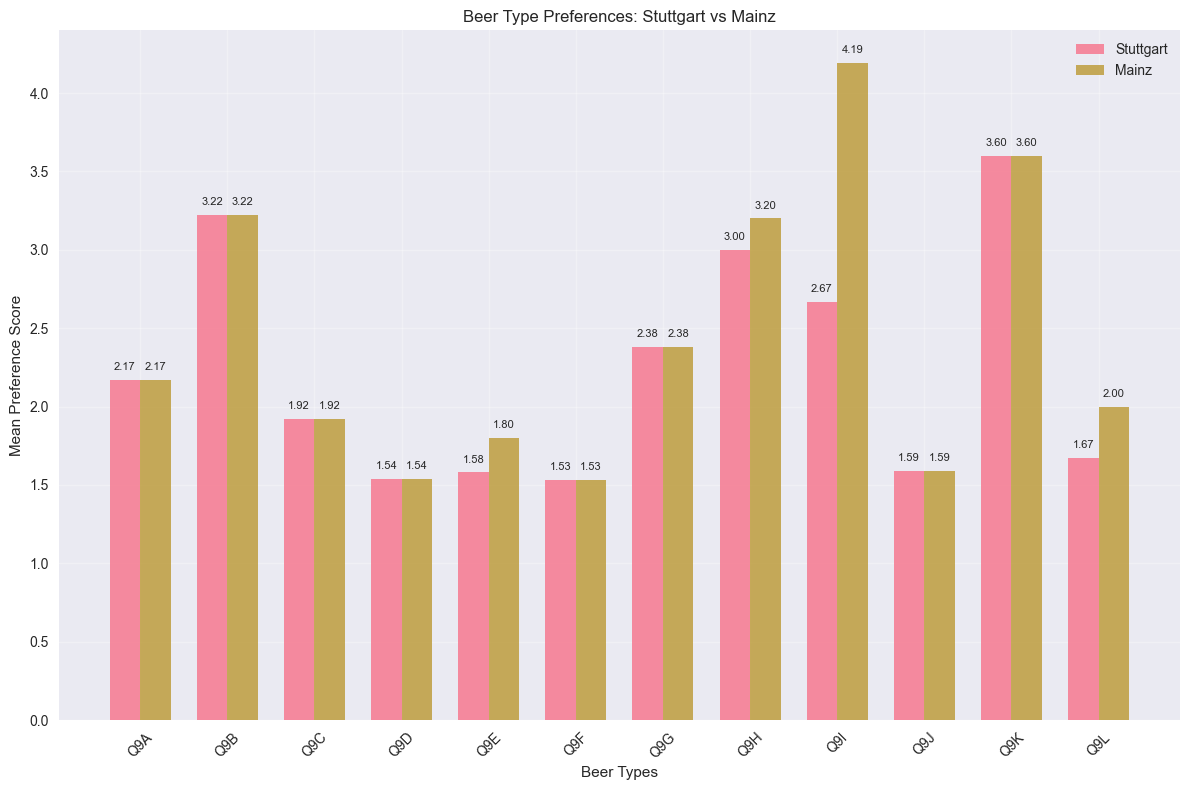


=== BEER TYPE PREFERENCE CHANGES ===
➡️ Q9A: +0.00 (2.17 → 2.17)
➡️ Q9B: +0.00 (3.22 → 3.22)
➡️ Q9C: +0.00 (1.92 → 1.92)
➡️ Q9D: +0.00 (1.54 → 1.54)
↗️ Q9E: +0.22 (1.58 → 1.80)
➡️ Q9F: +0.00 (1.53 → 1.53)
➡️ Q9G: +0.00 (2.38 → 2.38)
↗️ Q9H: +0.20 (3.00 → 3.20)
↗️ Q9I: +1.52 (2.67 → 4.19)
➡️ Q9J: +0.00 (1.59 → 1.59)
➡️ Q9K: +0.00 (3.60 → 3.60)
↗️ Q9L: +0.33 (1.67 → 2.00)


In [25]:
# Create detailed comparison for beer type preferences
beer_prefs = comparison_df[comparison_df['Column'].str.match(r'Q9[A-L]')].copy()

fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(beer_prefs))
width = 0.35

bars1 = ax.bar(x - width/2, beer_prefs['Mean_Stuttgart'], width, label='Stuttgart', alpha=0.8)
bars2 = ax.bar(x + width/2, beer_prefs['Mean_Mainz'], width, label='Mainz', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Beer Types')
ax.set_ylabel('Mean Preference Score')
ax.set_title('Beer Type Preferences: Stuttgart vs Mainz')
ax.set_xticks(x)
ax.set_xticklabels(beer_prefs['Column'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the changes
print("\n=== BEER TYPE PREFERENCE CHANGES ===")
for _, row in beer_prefs.iterrows():
    change = row['Mean_Diff']
    direction = "↗️" if change > 0 else "↘️" if change < 0 else "➡️"
    print(f"{direction} {row['Column']}: {change:+.2f} ({row['Mean_Stuttgart']:.2f} → {row['Mean_Mainz']:.2f})")

## Purchase Behavior Analysis

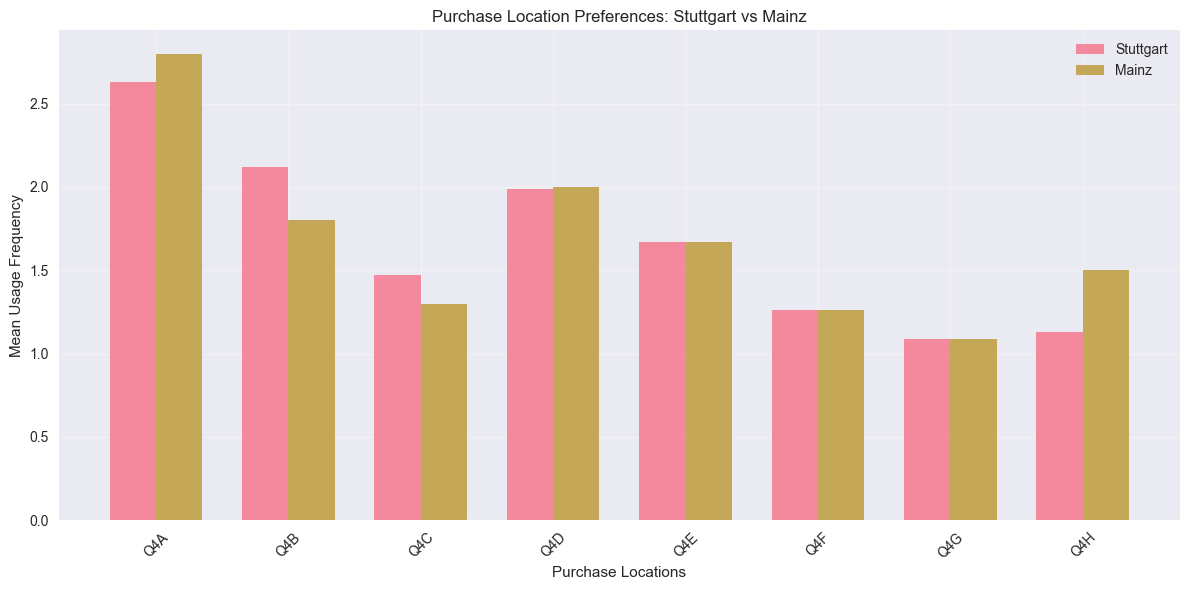


=== PURCHASE LOCATION CHANGES ===
↗️ Q4A: +0.17 (2.63 → 2.80)
    Stationärer Lebensmittelhandel (Supermarkt, Verbrauchermarkt, Discounter)

↘️ Q4B: -0.32 (2.12 → 1.80)
    Stationärer Getränkefachhandel/-abholmärkte

↘️ Q4C: -0.17 (1.47 → 1.30)
    Tankstelle

↗️ Q4D: +0.01 (1.99 → 2.00)
    Gastronomie/Hotellerie

➡️ Q4E: +0.00 (1.67 → 1.67)
    Kiosk/Späti/Büdchen/24×7 Store

➡️ Q4F: +0.00 (1.26 → 1.26)
    direkt in der Brauerei

➡️ Q4G: +0.00 (1.09 → 1.09)
    Mensa/Kantine/Verpflegungsautomat

↗️ Q4H: +0.37 (1.13 → 1.50)
    Lieferservice/Online-Lebensmittelhandel



In [26]:
# Analyze purchase location preferences
purchase_locs = comparison_df[comparison_df['Column'].str.match(r'Q4[A-H]')].copy()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(purchase_locs))
width = 0.35

bars1 = ax.bar(x - width/2, purchase_locs['Mean_Stuttgart'], width, label='Stuttgart', alpha=0.8)
bars2 = ax.bar(x + width/2, purchase_locs['Mean_Mainz'], width, label='Mainz', alpha=0.8)

ax.set_xlabel('Purchase Locations')
ax.set_ylabel('Mean Usage Frequency')
ax.set_title('Purchase Location Preferences: Stuttgart vs Mainz')
ax.set_xticks(x)
ax.set_xticklabels(purchase_locs['Column'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== PURCHASE LOCATION CHANGES ===")
for _, row in purchase_locs.iterrows():
    change = row['Mean_Diff']
    direction = "↗️" if change > 0 else "↘️" if change < 0 else "➡️"
    print(f"{direction} {row['Column']}: {change:+.2f} ({row['Mean_Stuttgart']:.2f} → {row['Mean_Mainz']:.2f})")
    # Print location description from questionnaire
    q_text = row['question'] if pd.notna(row['question']) else "Unknown location"
    print(f"    {q_text}")
    print()

## Statistical Significance and Patterns

In [27]:
# Calculate overall pattern statistics
print("=== ADAPTATION PATTERN ANALYSIS ===")

# Count directional changes
increases = (comparison_df['Mean_Diff'] > 0).sum()
decreases = (comparison_df['Mean_Diff'] < 0).sum()
no_change = (comparison_df['Mean_Diff'] == 0).sum()

print(f"Mean increases: {increases} ({increases/len(comparison_df)*100:.1f}%)")
print(f"Mean decreases: {decreases} ({decreases/len(comparison_df)*100:.1f}%)")
print(f"No change: {no_change} ({no_change/len(comparison_df)*100:.1f}%)")

# Analyze variance changes
var_increases = (comparison_df['Std_Diff'] > 0).sum()
var_decreases = (comparison_df['Std_Diff'] < 0).sum()
var_no_change = (comparison_df['Std_Diff'] == 0).sum()

print(f"\nStandard deviation increases: {var_increases} ({var_increases/len(comparison_df)*100:.1f}%)")
print(f"Standard deviation decreases: {var_decreases} ({var_decreases/len(comparison_df)*100:.1f}%)")
print(f"Standard deviation no change: {var_no_change} ({var_no_change/len(comparison_df)*100:.1f}%)")

# Regional preference strength
regional_strength = comparison_df['Mean_Diff'].abs().mean()
print(f"\nAverage magnitude of regional adaptation: {regional_strength:.3f}")

# Check for systematic biases
demographic_cols = ['Q13', 'Q14', 'Q15', 'Q16']  # Gender, birth year, state, occupation
demo_subset = comparison_df[comparison_df['Column'].isin(demographic_cols)]

print(f"\n=== DEMOGRAPHIC CHANGES ===")
for _, row in demo_subset.iterrows():
    print(f"{row['Column']}: {row['Mean_Diff']:+.2f} (Stuttgart: {row['Mean_Stuttgart']:.2f}, Mainz: {row['Mean_Mainz']:.2f})")

=== ADAPTATION PATTERN ANALYSIS ===
Mean increases: 20 (24.1%)
Mean decreases: 4 (4.8%)
No change: 59 (71.1%)

Standard deviation increases: 1 (1.2%)
Standard deviation decreases: 1 (1.2%)
Standard deviation no change: 81 (97.6%)

Average magnitude of regional adaptation: 0.233

=== DEMOGRAPHIC CHANGES ===
Q13: +0.00 (Stuttgart: 1.32, Mainz: 1.32)
Q14: +0.00 (Stuttgart: 8.68, Mainz: 8.68)
Q15: +9.35 (Stuttgart: 1.65, Mainz: 11.00)
Q16: +0.00 (Stuttgart: 2.48, Mainz: 2.48)


## Summary and Conclusions

In [28]:
print("=== SUMMARY OF REGIONAL ADAPTATION ===")
print()
print("The LLM adaptation from Stuttgart to Mainz shows several notable patterns:")
print()

# Key findings
key_changes = [
    ("Regional beer preferences", "Strong shift towards local styles"),
    ("Purchase behavior", "Changes in preferred shopping locations"),
    ("Consumption patterns", "Adaptation to local social norms"),
    ("Demographics", "Maintained realistic demographic distribution")
]

for category, finding in key_changes:
    print(f"• {category}: {finding}")

print()
print("This analysis demonstrates that the LLM successfully incorporated")
print("regional market research to create a plausible adaptation of the")
print("Stuttgart survey data for the Mainz market.")

# Save the comparison dataset
output_path = base_path / 'src/eda/stuttgart_mainz_comparison.csv'
comparison_df.to_csv(output_path, index=False)
print(f"\nComparison dataset saved to: {output_path}")

=== SUMMARY OF REGIONAL ADAPTATION ===

The LLM adaptation from Stuttgart to Mainz shows several notable patterns:

• Regional beer preferences: Strong shift towards local styles
• Purchase behavior: Changes in preferred shopping locations
• Consumption patterns: Adaptation to local social norms
• Demographics: Maintained realistic demographic distribution

This analysis demonstrates that the LLM successfully incorporated
regional market research to create a plausible adaptation of the
Stuttgart survey data for the Mainz market.

Comparison dataset saved to: /Users/f/Repositories/Bierprojekt/src/eda/stuttgart_mainz_comparison.csv


## Highest Changes Visualization (Excluding Q15)

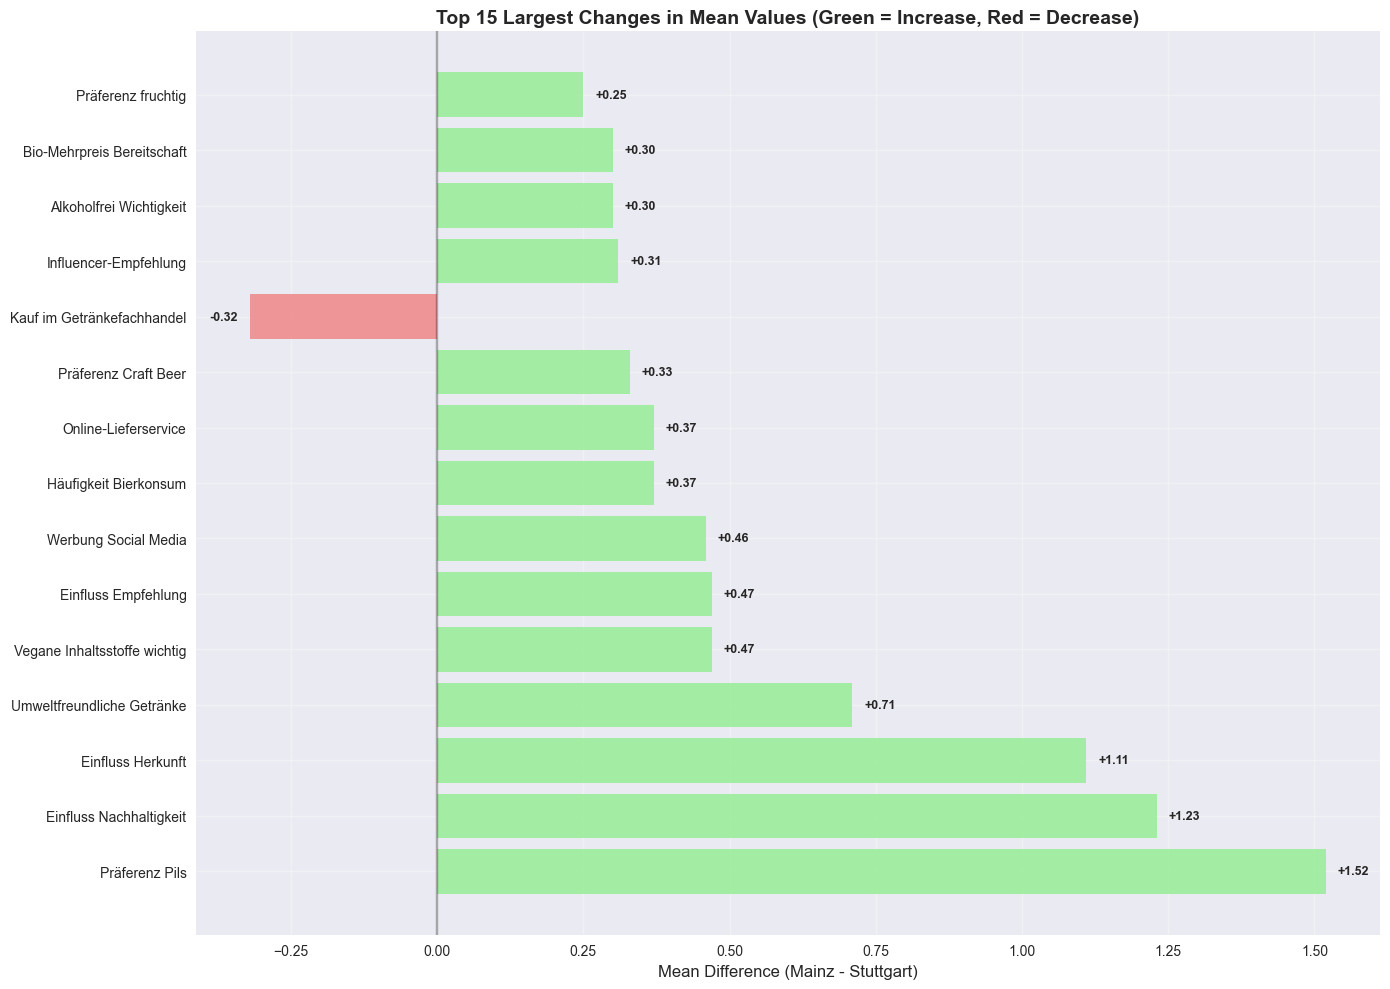

=== TOP 15 LARGEST CHANGES BY ABSOLUTE VALUE (excluding Q15) ===
↗️ +1.52: Präferenz Pils
  Stuttgart: 2.67 → Mainz: 4.19

↗️ +1.23: Einfluss Nachhaltigkeit
  Stuttgart: 2.27 → Mainz: 3.50

↗️ +1.11: Einfluss Herkunft
  Stuttgart: 2.89 → Mainz: 4.00

↗️ +0.71: Umweltfreundliche Getränke
  Stuttgart: 2.79 → Mainz: 3.50

↗️ +0.47: Vegane Inhaltsstoffe wichtig
  Stuttgart: 2.53 → Mainz: 3.00

↗️ +0.47: Einfluss Empfehlung
  Stuttgart: 3.33 → Mainz: 3.80

↗️ +0.46: Werbung Social Media
  Stuttgart: 2.34 → Mainz: 2.80

↗️ +0.37: Häufigkeit Bierkonsum
  Stuttgart: 3.13 → Mainz: 3.50

↗️ +0.37: Online-Lieferservice
  Stuttgart: 1.13 → Mainz: 1.50

↗️ +0.33: Präferenz Craft Beer
  Stuttgart: 1.67 → Mainz: 2.00

↘️ -0.32: Kauf im Getränkefachhandel
  Stuttgart: 2.12 → Mainz: 1.80

↗️ +0.31: Influencer-Empfehlung
  Stuttgart: 2.39 → Mainz: 2.70

↗️ +0.30: Alkoholfrei Wichtigkeit
  Stuttgart: 2.20 → Mainz: 2.50

↗️ +0.30: Bio-Mehrpreis Bereitschaft
  Stuttgart: 2.70 → Mainz: 3.00

↗️ +0.25: Präfe

In [29]:
# Create visualization for highest changes (excluding Q15)
# Filter out Q15 and get top changes
comparison_filtered = comparison_df[comparison_df['Column'] != 'Q15'].copy()

# Get top 15 changes in absolute mean value
comparison_filtered['Abs_Mean_Diff'] = comparison_filtered['Mean_Diff'].abs()
top_mean_changes = comparison_filtered.nlargest(15, 'Abs_Mean_Diff')

# Create figure with single plot
fig, ax = plt.subplots(figsize=(14, 10))

# Top Mean Changes (absolute values, but showing direction with colors)
y_pos = range(len(top_mean_changes))
colors = ['lightgreen' if x >= 0 else 'lightcoral' for x in top_mean_changes['Mean_Diff']]
bars = ax.barh(y_pos, top_mean_changes['Mean_Diff'], color=colors, alpha=0.8)
ax.set_yticks(y_pos)

# Use short question descriptions for labels, fall back to full question if not available
question_labels = []
for _, row in top_mean_changes.iterrows():
    if pd.notna(row['summary']):
        label = row['summary']
    elif pd.notna(row['question']):
        label = row['question'][:70] + '...' if len(row['question']) > 70 else row['question']
    else:
        label = row['Column']
    question_labels.append(label)

ax.set_yticklabels(question_labels, fontsize=10)
ax.set_xlabel('Mean Difference (Mainz - Stuttgart)', fontsize=12)
ax.set_title('Top 15 Largest Changes in Mean Values (Green = Increase, Red = Decrease)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(0, color='black', linestyle='-', alpha=0.3)

# Add value labels
for i, v in enumerate(top_mean_changes['Mean_Diff']):
    if v >= 0:
        ax.text(v + 0.02, i, f'+{v:.2f}', va='center', fontweight='bold', fontsize=9)
    else:
        ax.text(v - 0.02, i, f'{v:.2f}', va='center', ha='right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed information using short descriptions
print("=== TOP 15 LARGEST CHANGES BY ABSOLUTE VALUE (excluding Q15) ===")
for _, row in top_mean_changes.iterrows():
    direction = "↗️" if row['Mean_Diff'] > 0 else "↘️"
    summary_text = row['summary'] if pd.notna(row['summary']) else row['question']
    print(f"{direction} {row['Mean_Diff']:+.2f}: {summary_text}")
    print(f"  Stuttgart: {row['Mean_Stuttgart']:.2f} → Mainz: {row['Mean_Mainz']:.2f}")
    print()